# Data Processing for AI4I 2020 Predictive Maintenance
    This notebook covers:
    - Loading the dataset
    - Basic cleaning and preprocessing
    - Encoding categorical features
    - Feature scaling
    - Train/test split
    - Initial EDA overview

Dataset: AI4I 2020 Predictive Maintenance (UCI ML Repository)
<a href="https://archive.ics.uci.edu/dataset/601/ai4i+2020+predictive+maintenance+dataset">#

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline

import joblib

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")


## Load the dataset and Visualize relevant data

In [2]:
df = pd.read_csv("../data/ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
print(df["Product ID"].value_counts())
print("Dispersion of the Product id Value Count :",df["Product ID"].value_counts().max() - df["Product ID"].value_counts().min())


Product ID
M14860    1
L47181    1
L47182    1
L47183    1
L47184    1
         ..
M24855    1
H39410    1
M24857    1
H39412    1
M24859    1
Name: count, Length: 10000, dtype: int64
Dispersion of the Product id Value Count : 0


Product Id is not relevant to our analysis

In [4]:
print(df["Type"].value_counts())

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


In [5]:
df = df.rename(columns={
    'Air temperature [K]': 'Air temperature',
    'Process temperature [K]': 'Process temperature',
    'Rotational speed [rpm]': 'Rotational speed',
    'Torque [Nm]': 'Torque',
    'Tool wear [min]': 'Tool wear'
})

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   UDI                  10000 non-null  int64  
 1   Product ID           10000 non-null  str    
 2   Type                 10000 non-null  str    
 3   Air temperature      10000 non-null  float64
 4   Process temperature  10000 non-null  float64
 5   Rotational speed     10000 non-null  int64  
 6   Torque               10000 non-null  float64
 7   Tool wear            10000 non-null  int64  
 8   Machine failure      10000 non-null  int64  
 9   TWF                  10000 non-null  int64  
 10  HDF                  10000 non-null  int64  
 11  PWF                  10000 non-null  int64  
 12  OSF                  10000 non-null  int64  
 13  RNF                  10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
memory usage: 1.1 MB


In [7]:
df.isnull().sum()

UDI                    0
Product ID             0
Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Machine failure        0
TWF                    0
HDF                    0
PWF                    0
OSF                    0
RNF                    0
dtype: int64

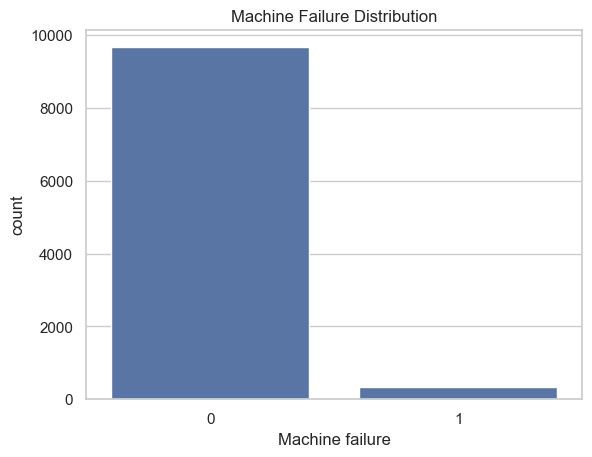

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [8]:
sns.countplot(x=df["Machine failure"])
plt.title("Machine Failure Distribution")
plt.show()

df["Machine failure"].value_counts(normalize=True) * 100


In [9]:
df['temp_diff'] = df['Process temperature'] - df['Air temperature']
df['power'] = df['Rotational speed'] * df['Torque']  
df['wear_per_rpm'] = df['Tool wear'] / (df['Rotational speed'] + 1e-6) 

## Separate features and target

In [10]:
X = df.drop(columns=["Machine failure"])

y = df["Machine failure"]

# Remove ID columns
id_cols = ['UDI', 'Product ID']
X = X.drop(columns=id_cols)

# Remove failure mode columns (data leakage)
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
X = X.drop(columns=failure_cols)

print(X.head())

X.shape, y.shape

  Type  Air temperature  Process temperature  Rotational speed  Torque  \
0    M            298.1                308.6              1551    42.8   
1    L            298.2                308.7              1408    46.3   
2    L            298.1                308.5              1498    49.4   
3    L            298.2                308.6              1433    39.5   
4    L            298.2                308.7              1408    40.0   

   Tool wear  temp_diff    power  wear_per_rpm  
0          0       10.5  66382.8      0.000000  
1          3       10.5  65190.4      0.002131  
2          5       10.4  74001.2      0.003338  
3          7       10.4  56603.5      0.004885  
4          9       10.5  56320.0      0.006392  


((10000, 9), (10000,))

## Identify categorical and numeric features

In [11]:
cat_features = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
num_features = X.select_dtypes(exclude=['object', 'category', 'string']).columns.tolist()



cat_features, num_features

(['Type'],
 ['Air temperature',
  'Process temperature',
  'Rotational speed',
  'Torque',
  'Tool wear',
  'temp_diff',
  'power',
  'wear_per_rpm'])

In [12]:
def plot_on_grid(df, features, plot_func, titles, suptitle=None,
                 figsize=(15, 9), nrows=2, ncols=16,
                 positions=None, hspace=0.45, wspace=0.35):
    """
    Generic function to plot several plots on a custom GridSpec layout

    Parameters:
    - plot_func: sns.histplot, sns.boxplot, etc. (the plotting function)
    - titles: list of title strings (one per feature)
    - positions: list of (row_start, row_end, col_start, col_end) slices
                 if None → uses a default staggered layout
    """
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(nrows, ncols, figure=fig, hspace=hspace, wspace=wspace)

    if positions is None:
        # Default staggered layout like in your example
        positions = [
            (0, 0, 4),    # ax1: row 0, cols 0–4
            (0, 6, 10),   # ax2
            (0, 12, 16),  # ax3
            (1, 3, 7),    # ax4
            (1, 9, 13),   # ax5
        ]

    axes = []
    for row_start, col_start, col_end in positions:
        ax = fig.add_subplot(gs[row_start, col_start:col_end])
        axes.append(ax)

    for ax, col, title in zip(axes, features, titles):
        plot_func(data=df, x=col, ax=ax) if plot_func == sns.histplot else \
        plot_func(x=df["Machine failure"], y=df[col], ax=ax)   # adjust for boxplot

        ax.set_title(title)
        # Optional: set xlabel/ylabel depending on plot type
        if plot_func == sns.histplot:
            ax.set_xlabel(col)
            ax.set_ylabel("Count")
        else:
            ax.set_xlabel("Machine Failure")
            ax.set_ylabel(col)

    if suptitle:
        fig.suptitle(suptitle, fontsize=16, y=0.98)

    return fig, axes

(<Figure size 1500x900 with 5 Axes>,
 [<Axes: title={'center': 'Distribution of Air temperature'}, xlabel='Air temperature', ylabel='Count'>,
  <Axes: title={'center': 'Distribution of Process temperature'}, xlabel='Process temperature', ylabel='Count'>,
  <Axes: title={'center': 'Distribution of Rotational speed'}, xlabel='Rotational speed', ylabel='Count'>,
  <Axes: title={'center': 'Distribution of Torque'}, xlabel='Torque', ylabel='Count'>,
  <Axes: title={'center': 'Distribution of Tool wear'}, xlabel='Tool wear', ylabel='Count'>])

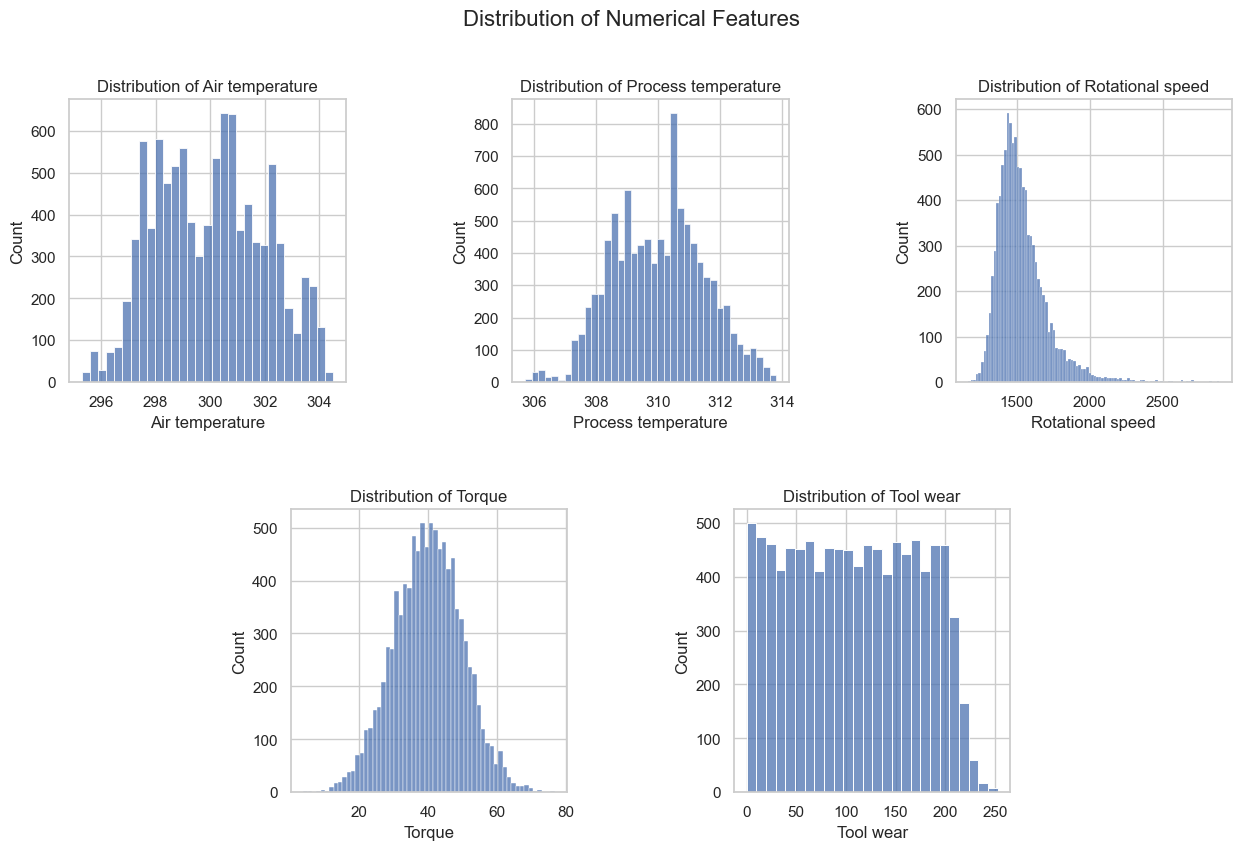

In [13]:
plot_on_grid(
    df=df,
    features=num_features,
    plot_func=sns.histplot,
    titles=[f"Distribution of {col}" for col in num_features],
    suptitle="Distribution of Numerical Features"
)

(<Figure size 1500x900 with 5 Axes>,
 [<Axes: title={'center': 'Air temperature by Machine Failure'}, xlabel='Machine Failure', ylabel='Air temperature'>,
  <Axes: title={'center': 'Process temperature by Machine Failure'}, xlabel='Machine Failure', ylabel='Process temperature'>,
  <Axes: title={'center': 'Rotational speed by Machine Failure'}, xlabel='Machine Failure', ylabel='Rotational speed'>,
  <Axes: title={'center': 'Torque by Machine Failure'}, xlabel='Machine Failure', ylabel='Torque'>,
  <Axes: title={'center': 'Tool wear by Machine Failure'}, xlabel='Machine Failure', ylabel='Tool wear'>])

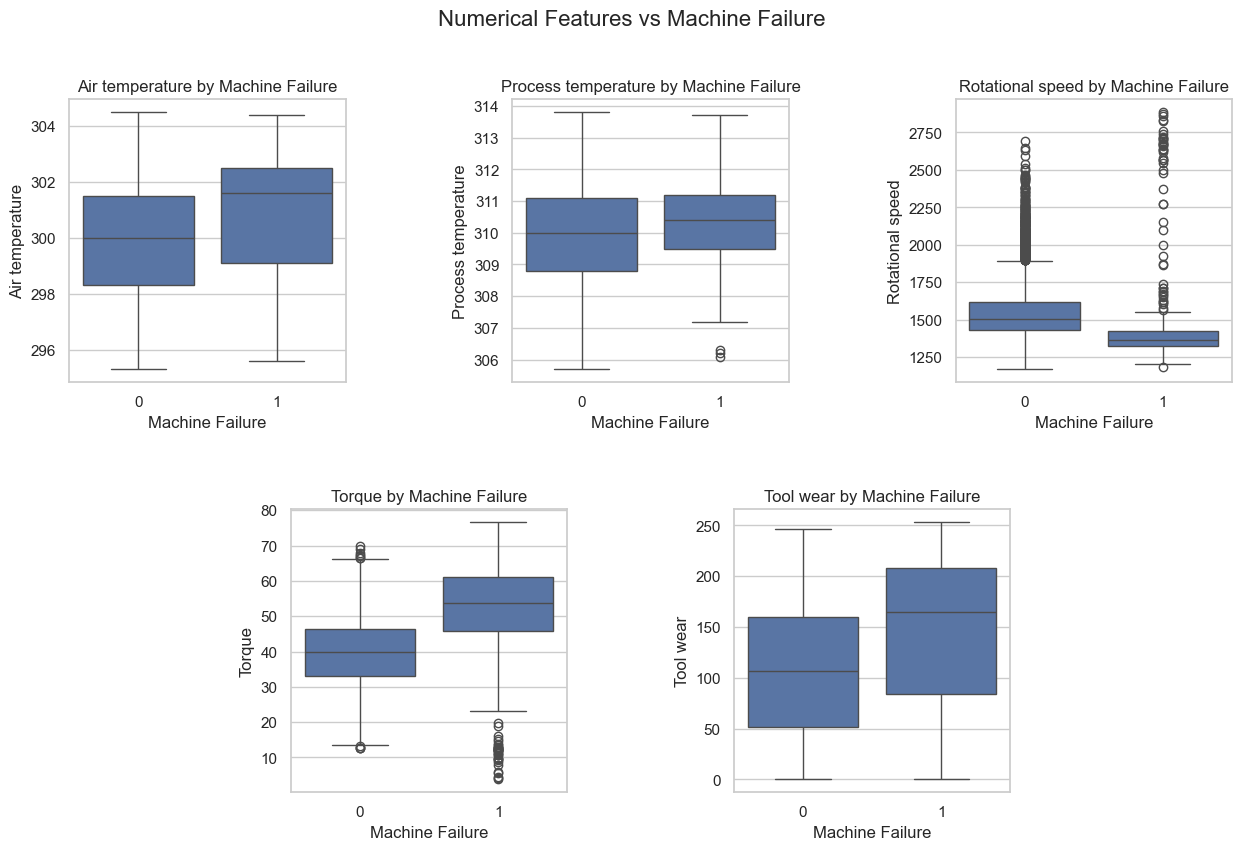

In [14]:
plot_on_grid(
    df=df,
    features=num_features,
    plot_func=sns.boxplot,
    titles=[f"{col} by Machine Failure" for col in num_features],
    suptitle="Numerical Features vs Machine Failure"
)

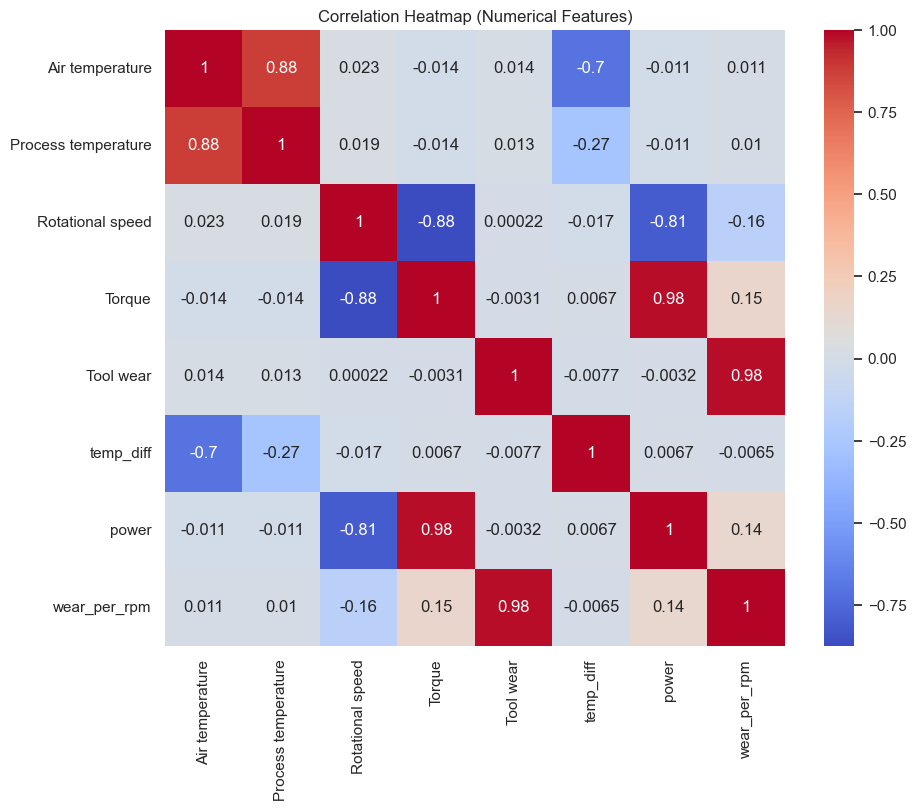

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_features].corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()

## Train / Test split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train.shape, X_test.shape

((8000, 9), (2000, 9))

## Preprocessing pipeline
- OneHotEncode the categoricals
- Standardize the numerics

data uses different physical units (Kelvin, rpm, Nm, minutes).

In [17]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, make_column_selector(dtype_include=np.number)),
        ('cat', categorical_transformer, make_column_selector(dtype_include=['object', 'category']))
    ],
    remainder='passthrough'
)


## Apply preprocessing to the training data

In [18]:
preprocessor.fit(X_train)

final_num_features = num_features

ohe = preprocessor.named_transformers_['cat']['onehot']
final_cat_features = ohe.get_feature_names_out(cat_features)

final_features = list(final_num_features) + list(final_cat_features)

X_train_transformed = preprocessor.transform(X_train)
print("Shape après transformation :", X_train_transformed.shape)
print("Nouvelles features :", final_features)

Shape après transformation : (8000, 11)
Nouvelles features : ['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'temp_diff', 'power', 'wear_per_rpm', 'Type_H', 'Type_L', 'Type_M']


In [ ]:
joblib.dump(preprocessor, "../artifacts/preprocessor.pkl")
joblib.dump(final_features, "../artifacts/feature_names.pkl")

print("Preprocessor saved.  Feature names saved.")

Preprocessor saved.  Feature names saved.


: 

## Notebook Output Artifacts

### This notebook is responsible only for data preprocessing.

It produces:

- preprocessor.pkl → Scikit-learn ColumnTransformer

- feature_names.pkl → Final feature list after encoding

These artifacts are used later by the model training pipeline.